## Ideia inicial para primeira submissão:

Regressão Linear usando somente a diferença de seed entre os dois times.

Montar os dados somente com as seguintes informações:

- Temporada
- ID time A
- ID time B
- SeedDif (SeedA - SeedB)
- Target (ScoreA - ScoreB)

Vamos utilizar os seguintes CSVs nesse primeiro teste.

Informações sobre as seeds:
- MNCAATourneySeeds.csv
- WNCAATourneySeeds.csv

Informações dos placares:
- MNCAATourneyCompactResults.csv
- WNCAATourneyCompactResults.csv

Exemplo da Submissão no Kaggle:
- SampleSubmissionStage2.csv

## Configuração do experimento
As escolhas do experimento ficam nesta célula: dados, features, modelo,
hiperparâmetros e temporadas. A validação usa somente anos anteriores ao escolhido.
O treino final usa somente anos anteriores à temporada de previsão.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

diretorio_atual = Path.cwd().resolve()
raiz = next(
    (p for p in [diretorio_atual, *diretorio_atual.parents] if (p / "raw_data").is_dir()),
    None,
)
if raiz is None:
    raise FileNotFoundError("Pasta raw_data n?o encontrada.")
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.data_processing import carregar_dados, preparar_seeds, organizar_jogos
from src.features import adicionar_seeds
from src.models import criar_regressao_linear, criar_random_forest, criar_xgboost
from src.metrics import avaliar_modelo, logistic_brier
from src.submission import preparar_confrontos, prever_confrontos, salvar_submission

PASTA_DADOS = raiz / "raw_data"
CATEGORIAS = {"M": "Masculino", "W": "Feminino"}
STAGE = 2
TEMPORADA_VALIDACAO = 2025
TEMPORADA_PREVISAO = 2026
FEATURES = ["SeedDif"]
CRIAR_MODELO = criar_regressao_linear
PARAMETROS_MODELO = {"fit_intercept": False}
NOME_SUBMISSION = f"submission_baseline_linear_{TEMPORADA_PREVISAO}.csv"

if TEMPORADA_VALIDACAO >= TEMPORADA_PREVISAO:
    raise ValueError("A valida??o deve ser anterior ? temporada de previs?o.")

## Carregar e preparar os dados
A organização de A/B e do target fica em data_processing; a criação de SeedDif,
em features. Guardamos todas as colunas para inspeção, mas o modelo recebe
somente FEATURES. Seeds menores representam melhores posições no torneio.

In [2]:
dados = {
    categoria: carregar_dados(PASTA_DADOS, categoria, stage=STAGE)
    for categoria in CATEGORIAS
}
seeds = {
    categoria: preparar_seeds(base["seeds"])
    for categoria, base in dados.items()
}
jogos = {
    categoria: adicionar_seeds(organizar_jogos(base["resultados"]), seeds[categoria])
    for categoria, base in dados.items()
}
sample_submission = dados["M"]["sample_submission"]

display(pd.DataFrame([
    {
        "Categoria": nome,
        "Jogos": len(jogos[categoria]),
        "Primeira temporada": jogos[categoria]["Season"].min(),
        "?ltima temporada": jogos[categoria]["Season"].max(),
    }
    for categoria, nome in CATEGORIAS.items()
]))
display(jogos["M"].head())
display(jogos["W"].head())

,Categoria,Jogos,Primeira temporada,?ltima temporada
0,Masculino,2585,1985,2025
1,Feminino,1717,1998,2025


,Season,DayNum,TeamA,TeamB,ScoreA,ScoreB,Target,SeedA,SeedB,TemDuasSeeds,SeedDif
0,1985,136,1116,1234,63,54,9,9,8,True,1
1,1985,136,1120,1345,59,58,1,11,6,True,5
2,1985,136,1207,1250,68,43,25,1,16,True,-15
3,1985,136,1229,1425,58,55,3,9,8,True,1
4,1985,136,1242,1325,49,38,11,3,14,True,-11


,Season,DayNum,TeamA,TeamB,ScoreA,ScoreB,Target,SeedA,SeedB,TemDuasSeeds,SeedDif
0,1998,137,3104,3422,94,46,48,2,15,True,-13
1,1998,137,3112,3365,75,63,12,3,14,True,-11
2,1998,137,3163,3193,93,52,41,2,15,True,-13
3,1998,137,3198,3266,59,45,14,7,10,True,-3
4,1998,137,3203,3208,74,72,2,10,7,True,3


## Avaliar o experimento
avaliar_modelo treina uma cópia do modelo com as temporadas anteriores e retorna
o modelo treinado, as previsões e o resumo da avaliação.
O Logistic Brier usa a média de (sigmoid(Pred / 7) - sigmoid(Target / 7))².
Quanto menor, melhor. O score combinado reúne os jogos das duas categorias.

Referência: [competição Logistic Brier](https://www.kaggle.com/competitions/march-machine-learning-mania-2026-logistic-brier).

In [3]:
avaliacoes = {
    categoria: avaliar_modelo(
        jogos[categoria],
        CRIAR_MODELO(**PARAMETROS_MODELO),
        TEMPORADA_VALIDACAO,
        features=FEATURES,
    )
    for categoria in CATEGORIAS
}
display(pd.DataFrame([
    {"Categoria": CATEGORIAS[categoria], **resultado["resumo"]}
    for categoria, resultado in avaliacoes.items()
]))

validacao = pd.concat([
    resultado["previsoes"].assign(Categoria=CATEGORIAS[categoria])
    for categoria, resultado in avaliacoes.items()
], ignore_index=True)
score_combinado = logistic_brier(validacao["Target"], validacao["Pred"])
score_zero = logistic_brier(validacao["Target"], np.zeros(len(validacao)))
display(pd.DataFrame([{
    "Categoria": "Combinado",
    "Jogos": len(validacao),
    "Logistic Brier": score_combinado,
    "Logistic Brier - margem zero": score_zero,
    "Ganho sobre margem zero": score_zero - score_combinado,
}]))
display(validacao.head())

,Categoria,Temporada de validação,Primeira temporada de treino,Última temporada de treino,Jogos de treino,Jogos de validação,Logistic Brier,Logistic Brier - margem zero,Ganho sobre margem zero
0,Masculino,2025,1985,2024,2518,67,0.057806,0.111677,0.053871
1,Feminino,2025,1998,2024,1650,67,0.050545,0.146443,0.095899


,Categoria,Jogos,Logistic Brier,Logistic Brier - margem zero,Ganho sobre margem zero
0,Combinado,134,0.054175,0.12906,0.074885


,Season,DayNum,TeamA,TeamB,ScoreA,ScoreB,Target,SeedA,SeedB,TemDuasSeeds,SeedDif,Pred,Categoria
0,2025,134,1106,1384,70,68,2,16,16,True,0,0.000000,Masculino
1,2025,134,1314,1361,95,68,27,11,11,True,0,0.000000,Masculino
2,2025,135,1110,1291,72,83,-11,16,16,True,0,0.000000,Masculino
3,2025,135,1400,1462,80,86,-6,11,11,True,0,0.000000,Masculino
4,2025,136,1116,1242,79,72,7,10,7,True,3,-3.564095,Masculino


## Treino final
Após a avaliação, treinamos modelos novos com todo o histórico anterior à
temporada de previsão, incluindo a temporada usada na validação.

In [4]:
modelos_finais = {}
resumo_treino = []
for categoria, nome in CATEGORIAS.items():
    treino = jogos[categoria].loc[
        jogos[categoria]["Season"] < TEMPORADA_PREVISAO
    ]
    if treino.empty:
        raise ValueError(f"N?o h? hist?rico para treinar: {nome}.")
    modelo = CRIAR_MODELO(**PARAMETROS_MODELO)
    modelo.fit(treino[FEATURES], treino["Target"])
    modelos_finais[categoria] = modelo
    resumo_treino.append({
        "Categoria": nome,
        "Modelo": type(modelo).__name__,
        "Jogos de treino": len(treino),
        "?ltima temporada": treino["Season"].max(),
    })
display(pd.DataFrame(resumo_treino))

,Categoria,Modelo,Jogos de treino,?ltima temporada
0,Masculino,LinearRegression,2585,2025
1,Feminino,LinearRegression,1717,2025


## Preparar confrontos e gerar a submissão
A submissão usa a mesma função adicionar_seeds aplicada ao histórico.
Pares envolvendo times sem seed recebem margem zero, como no baseline original.
Quando adicionarmos novas features, elas também precisarão ser calculadas aqui,
antes de prever, usando apenas informações disponíveis antes do torneio.

In [5]:
confrontos = preparar_confrontos(
    sample_submission,
    seeds["M"], seeds["W"],
    dados["M"]["times"]["TeamID"], dados["W"]["times"]["TeamID"],
    temporada=TEMPORADA_PREVISAO,
)
confrontos = prever_confrontos(
    confrontos, modelos_finais["M"], modelos_finais["W"], features=FEATURES,
)
display(confrontos.groupby("Categoria").agg(
    Total_confrontos=("ID", "size"),
    Confrontos_com_duas_seeds=("TemDuasSeeds", "sum"),
))
display(confrontos.loc[confrontos["TemDuasSeeds"]].head())

,Total_confrontos,Confrontos_com_duas_seeds
Categoria,,
Feminino,65703,2278
Masculino,66430,2278


,ID,Season,TeamA,TeamB,Categoria,SeedA,SeedB,TemDuasSeeds,SeedDif,Pred
727,2026_1103_1104,2026,1103,1104,Masculino,12.0,4.0,True,8.0,-9.592765
734,2026_1103_1112,2026,1103,1112,Masculino,12.0,1.0,True,11.0,-13.190052
738,2026_1103_1116,2026,1103,1116,Masculino,12.0,4.0,True,8.0,-9.592765
758,2026_1103_1140,2026,1103,1140,Masculino,12.0,6.0,True,6.0,-7.194574
772,2026_1103_1155,2026,1103,1155,Masculino,12.0,8.0,True,4.0,-4.796383


## Salvar o CSV
Pred contém a margem bruta para o time de menor ID, sem transformação logística.
O arquivo é salvo localmente; seu nome está na configuração do experimento.

In [6]:
caminho_submission = salvar_submission(
    confrontos, sample_submission, raiz / "submissions" / NOME_SUBMISSION,
)
print(f"Arquivo salvo: {caminho_submission}")
print(f"Total de previs?es: {len(confrontos):,}")
display(confrontos[["ID", "Pred"]].head())

Arquivo salvo: C:\Users\davis\Documents\vscode\March-Mania---Comp-CDados\submissions\submission_baseline_linear_2026.csv
Total de previs?es: 132,133


,ID,Pred
0,2026_1101_1102,0.0
1,2026_1101_1103,0.0
2,2026_1101_1104,0.0
3,2026_1101_1105,0.0
4,2026_1101_1106,0.0


## Visualizar a transformação logística
O gráfico é parte da análise e permanece no notebook.

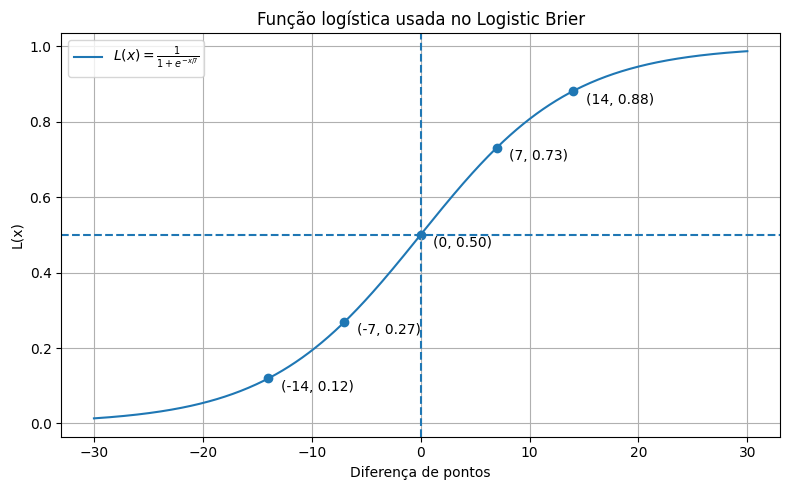

In [7]:
#Gerar gráfico Logistic Brier Score

import numpy as np
import matplotlib.pyplot as plt

def logistic(x, c=7):
    return 1 / (1 + np.exp(-x / c))

x = np.linspace(-30, 30, 500)
y = logistic(x)
pontos_x = np.array([-14, -7, 0, 7, 14])
pontos_y = logistic(pontos_x)


plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r"$L(x)=\frac{1}{1+e^{-x/7}}$")
plt.scatter(pontos_x, pontos_y)

for px, py in zip(pontos_x, pontos_y):
    plt.annotate(f"({px}, {py:.2f})", (px, py),
                 textcoords="offset points", xytext=(9, -9))


plt.axvline(0, linestyle="--")
plt.axhline(0.5, linestyle="--")
plt.title("Função logística usada no Logistic Brier")
plt.xlabel("Diferença de pontos")
plt.ylabel("L(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()